# LANGKAH 0: INSTALASI DAN IMPORT LIBRARY
## Menginstal library yang diperlukan dari Hugging Face dan Scikit-learn.

In [ ]:
!pip install wandb transformers datasets scikit-learn scikit-multilearn emoji torch --quiet

import pandas as pd
import torch
import torch.nn as nn
import emoji
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
from transformers import AutoTokenizer, AutoModel, AutoConfig, Trainer, TrainingArguments
from datasets import Dataset
from skmultilearn.model_selection import iterative_train_test_split
from dataclasses import dataclass
from transformers.tokenization_utils_base import PaddingStrategy, PreTrainedTokenizerBase
from typing import Any, Callable, Dict, List, NewType, Optional, Tuple, Union

# LANGKAH 1: MEMUAT DATASET
## Pastikan file 'dataset.csv' sudah ada di environment Anda.

In [ ]:
try:
    df = pd.read_csv('dataset.csv')
    print("Dataset 'dataset.csv' berhasil dimuat.")
except FileNotFoundError:
    print("Error: File 'dataset.csv' tidak ditemukan.")
    print("Silakan unggah file tersebut terlebih dahulu.")
    # Hentikan eksekusi jika file tidak ada
    exit()

Dataset 'dataset.csv' berhasil dimuat.


# LANGKAH 2: EKSTRAKSI EMOJI & PEMBUATAN VOCABULARY
## [MODIFIED] Langkah ini diubah untuk membuat vocabulary emoji terpisah, bukan untuk menambahkannya ke tokenizer BERT.

In [ ]:
print("\nMemindai dataset untuk mencari emoji unik...")
unique_emojis = set()
for text in df['text'].dropna():
    text_str = str(text)
    for character in text_str:
        if emoji.is_emoji(character):
            unique_emojis.add(character)

# [NEW] Membuat mapping dari emoji ke ID integer. Tambahkan token PAD untuk padding.
emoji_list = sorted(list(unique_emojis)) # Urutkan agar konsisten
emoji_to_id = {em: i for i, em in enumerate(emoji_list, 1)}
emoji_to_id['<PAD>'] = 0 # ID 0 untuk padding
id_to_emoji = {i: em for em, i in emoji_to_id.items()}
EMOJI_VOCAB_SIZE = len(emoji_to_id)
EMOJI_PAD_ID = emoji_to_id['<PAD>']


print(f"Ditemukan {len(unique_emojis)} emoji unik.")
print(f"Ukuran vocabulary emoji (termasuk <PAD>): {EMOJI_VOCAB_SIZE}")


Memindai dataset untuk mencari emoji unik...
Ditemukan 1040 emoji unik.
Ukuran vocabulary emoji (termasuk <PAD>): 1041


# LANGKAH 3: DEFINISI MODEL KUSTOM (EARLY FUSION)
## mendefinisikan arsitektur model baru untuk menggabungkan fitur BERT dan fitur emoji.

In [ ]:
class BertEmojiFusionModel(nn.Module):
    """
    Model kustom yang menggabungkan output dari IndoBERT dengan embedding emoji.
    """
    def __init__(self, model_name, num_labels, emoji_vocab_size, emoji_emb_dim=256, dropout_rate=0.2):
        super().__init__()
        self.num_labels = num_labels

        # 1. Muat model BERT dasar
        self.bert = AutoModel.from_pretrained(model_name)
        bert_hidden_size = self.bert.config.hidden_size

        # 2. Buat layer embedding khusus untuk emoji
        self.emoji_embeddings = nn.Embedding(emoji_vocab_size, emoji_emb_dim, padding_idx=EMOJI_PAD_ID)

        # 3. Definisikan classifier head (MLP)
        # Inputnya adalah gabungan dari [CLS] token BERT dan vektor emoji
        self.classifier = nn.Sequential(
            nn.Linear(bert_hidden_size + emoji_emb_dim, 512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(512, num_labels)
        )

        # [NEW] Simpan problem_type untuk kompatibilitas dengan Hugging Face Trainer
        self.config = self.bert.config
        self.config.problem_type = "multi_label_classification"


    def forward(
        self,
        input_ids: torch.Tensor,
        attention_mask: torch.Tensor,
        emoji_ids: torch.Tensor,
        labels: Optional[torch.Tensor] = None
    ):
        # 1. Dapatkan output dari BERT
        bert_outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        # Ambil representasi token [CLS] (output untuk seluruh kalimat)
        cls_output = bert_outputs.last_hidden_state[:, 0, :]

        # 2. Dapatkan embedding emoji dan hitung rata-ratanya
        emoji_mask = (emoji_ids != EMOJI_PAD_ID).float()
        emoji_embs = self.emoji_embeddings(emoji_ids)

        # Kalikan dengan mask untuk memastikan token PAD menjadi vektor nol
        emoji_embs = emoji_embs * emoji_mask.unsqueeze(-1)

        # Hitung rata-rata embedding, hindari pembagian dengan nol jika tidak ada emoji
        sum_embs = torch.sum(emoji_embs, dim=1)
        num_emojis = torch.sum(emoji_mask, dim=1).unsqueeze(-1)
        mean_emoji_embs = sum_embs / (num_emojis + 1e-9) # Tambah epsilon untuk stabilitas

        # 3. Gabungkan (concatenate) fitur BERT dan fitur emoji
        combined_features = torch.cat((cls_output, mean_emoji_embs), dim=1)

        # 4. Lewatkan fitur gabungan ke classifier untuk mendapatkan logits
        logits = self.classifier(combined_features)

        # 5. Hitung loss jika labels diberikan (selama training)
        loss = None
        if labels is not None:
            loss_fct = nn.BCEWithLogitsLoss()
            loss = loss_fct(logits, labels.float())

        # Kembalikan output dalam format yang dikenali oleh Trainer
        return (loss, logits) if loss is not None else (logits,)

# --- Inisialisasi Model ---
model_name = "indobenchmark/indobert-base-p1"
label_columns = ['joy', 'trust', 'fear', 'surprise', 'sadness', 'disgust', 'anger', 'anticipation']
num_labels = len(label_columns)
EMOJI_EMBEDDING_DIM = 128 # Dimensi embedding untuk emoji, bisa di-tune

print(f"\nMemuat tokenizer '{model_name}'...")
tokenizer = AutoTokenizer.from_pretrained(model_name)

print(f"Menginisialisasi model kustom 'BertEmojiFusionModel'...")
model = BertEmojiFusionModel(
    model_name=model_name,
    num_labels=num_labels,
    emoji_vocab_size=EMOJI_VOCAB_SIZE,
    emoji_emb_dim=EMOJI_EMBEDDING_DIM
)

print("Model dan tokenizer siap digunakan.")
# [MODIFIED] Bagian `resize_token_embeddings` dihapus karena kita tidak lagi menambahkan emoji ke vocab BERT.


Memuat tokenizer 'indobenchmark/indobert-base-p1'...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Menginisialisasi model kustom 'BertEmojiFusionModel'...


pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Model dan tokenizer siap digunakan.


# LANGKAH 4: PERSIAPAN DATASET UNTUK HUGGING FACE
## [MODIFIED] Mengubah format, melakukan split, dan memproses data untuk model kustom.

In [ ]:
# --- Pembagian Data (Sama seperti sebelumnya) ---
print("\nMemulai pembagian dataset dengan metode iterative_train_test_split...")
X = df['text'].to_numpy().reshape(-1, 1)
y = df[label_columns].to_numpy()

X_train_val, y_train_val, X_test, y_test = iterative_train_test_split(X, y, test_size=0.2)
X_train, y_train, X_val, y_val = iterative_train_test_split(X_train_val, y_train_val, test_size=0.2)

df_train = pd.DataFrame(X_train.flatten(), columns=['text'])
for i, col in enumerate(label_columns): df_train[col] = y_train[:, i]

df_val = pd.DataFrame(X_val.flatten(), columns=['text'])
for i, col in enumerate(label_columns): df_val[col] = y_val[:, i]

df_test = pd.DataFrame(X_test.flatten(), columns=['text'])
for i, col in enumerate(label_columns): df_test[col] = y_test[:, i]

print("\nMengubah format DataFrame menjadi Hugging Face Dataset...")
train_dataset_hf = Dataset.from_pandas(df_train)
eval_dataset_hf = Dataset.from_pandas(df_val)
test_dataset_hf = Dataset.from_pandas(df_test)

# --- [NEW] Fungsi Preprocessing Terpadu ---
def preprocess_data(examples):
    # 1. Tokenisasi teks untuk BERT
    tokenized_output = tokenizer(
        examples["text"], padding=False, truncation=True, max_length=128
    )

    # 2. Ekstraksi dan pemetaan emoji ke ID
    all_emoji_ids = []
    texts = [str(t) for t in examples["text"]]
    for text in texts:
        # Temukan emoji dalam teks dan ubah ke ID, jika tidak ada di vocab, abaikan
        ids = [emoji_to_id.get(char) for char in text if emoji.is_emoji(char) and char in emoji_to_id]
        # Hapus None values jika ada emoji yang tidak dikenali
        ids = [id for id in ids if id is not None]
        if not ids:
            ids = [EMOJI_PAD_ID] # Jika tidak ada emoji, beri satu token PAD
        all_emoji_ids.append(ids)

    # 3. Format label
    labels = [[float(examples[label][i]) for label in label_columns] for i in range(len(texts))]

    tokenized_output["emoji_ids"] = all_emoji_ids
    tokenized_output["labels"] = labels
    return tokenized_output

print("\nMelakukan tokenisasi, ekstraksi emoji, dan pemformatan label pada semua set data...")
train_dataset = train_dataset_hf.map(preprocess_data, batched=True, remove_columns=train_dataset_hf.column_names)
eval_dataset = eval_dataset_hf.map(preprocess_data, batched=True, remove_columns=eval_dataset_hf.column_names)
test_dataset = test_dataset_hf.map(preprocess_data, batched=True, remove_columns=test_dataset_hf.column_names)


print("\n--- Pembagian Data Selesai ---")
print(f"Jumlah data latih (train): {len(train_dataset)}")
print(f"Jumlah data validasi (validation): {len(eval_dataset)}")
print(f"Jumlah data uji (test): {len(test_dataset)}")




Memulai pembagian dataset dengan metode iterative_train_test_split...


model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]


Mengubah format DataFrame menjadi Hugging Face Dataset...

Melakukan tokenisasi, ekstraksi emoji, dan pemformatan label pada semua set data...


Map:   0%|          | 0/89888 [00:00<?, ? examples/s]

Map:   0%|          | 0/22221 [00:00<?, ? examples/s]

Map:   0%|          | 0/28236 [00:00<?, ? examples/s]


--- Pembagian Data Selesai ---
Jumlah data latih (train): 89888
Jumlah data validasi (validation): 22221
Jumlah data uji (test): 28236


## Visualisasi distribusi label


Menghitung dan menampilkan distribusi label di setiap set data...


/tmp/ipython-input-2030676071.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dist_df.index, y='Train', data=dist_df, ax=axes[0], palette='viridis')
/tmp/ipython-input-2030676071.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dist_df.index, y='Validation', data=dist_df, ax=axes[1], palette='viridis')
/tmp/ipython-input-2030676071.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dist_df.index, y='Test', data=dist_df, ax=axes[2], palette='viridis')


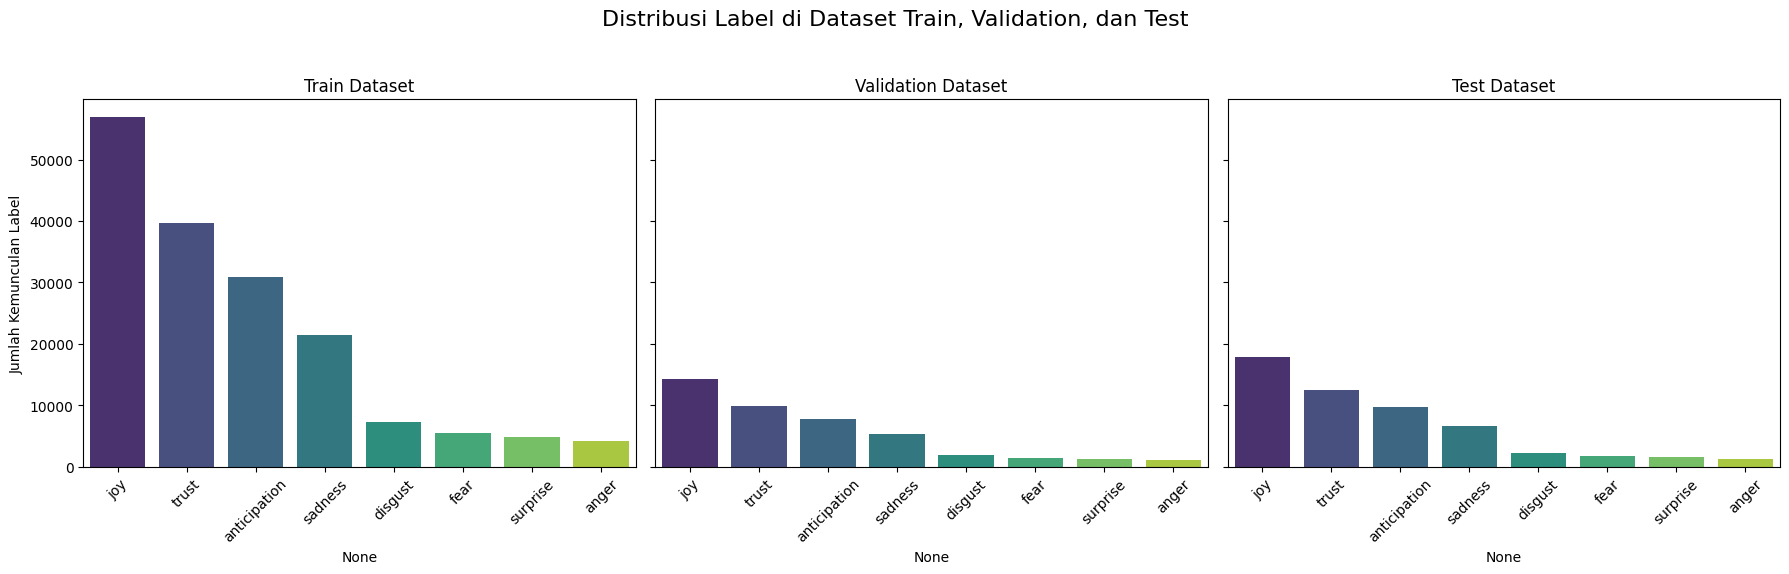


Distribusi label berhasil ditampilkan.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("\nMenghitung dan menampilkan distribusi label di setiap set data...")

def get_label_distribution(dataset_hf, label_columns):
    """Menghitung jumlah kemunculan setiap label dalam dataset Hugging Face."""
    df = dataset_hf.to_pandas()
    distribution = df[label_columns].sum().sort_values(ascending=False)
    return distribution

# Hitung distribusi untuk setiap set
train_label_dist = get_label_distribution(train_dataset_hf, label_columns)
eval_label_dist = get_label_distribution(eval_dataset_hf, label_columns)
test_label_dist = get_label_distribution(test_dataset_hf, label_columns)

# Buat DataFrame gabungan untuk plotting
dist_df = pd.DataFrame({
    'Train': train_label_dist,
    'Validation': eval_label_dist,
    'Test': test_label_dist
})

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
fig.suptitle('Distribusi Label di Dataset Train, Validation, dan Test', fontsize=16)

# Plot Train
sns.barplot(x=dist_df.index, y='Train', data=dist_df, ax=axes[0], palette='viridis')
axes[0].set_title('Train Dataset')
axes[0].set_ylabel('Jumlah Kemunculan Label')
axes[0].tick_params(axis='x', rotation=45)

# Plot Validation
sns.barplot(x=dist_df.index, y='Validation', data=dist_df, ax=axes[1], palette='viridis')
axes[1].set_title('Validation Dataset')
axes[1].set_ylabel('') # Hide y-label as it's shared
axes[1].tick_params(axis='x', rotation=45)

# Plot Test
sns.barplot(x=dist_df.index, y='Test', data=dist_df, ax=axes[2], palette='viridis')
axes[2].set_title('Test Dataset')
axes[2].set_ylabel('') # Hide y-label as it's shared
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

print("\nDistribusi label berhasil ditampilkan.")

# LANGKAH 4.5: MEMBUAT DATA COLLATOR KUSTOM
## Collator ini akan menangani padding untuk `input_ids` dan `emoji_ids` secara bersamaan.

In [ ]:
@dataclass
class CustomDataCollator:
    tokenizer: PreTrainedTokenizerBase
    padding: Union[bool, str, PaddingStrategy] = True
    max_length: Optional[int] = None
    pad_to_multiple_of: Optional[int] = None

    def __call__(self, features: List[Dict[str, Any]]) -> Dict[str, Any]:
        # Pisahkan label, emoji_ids, dan fitur lainnya
        labels = [feature.pop("labels") for feature in features]
        emoji_ids = [feature.pop("emoji_ids") for feature in features]

        # Gunakan padding bawaan tokenizer untuk input_ids, attention_mask, dll.
        batch = self.tokenizer.pad(
            features,
            padding=self.padding,
            max_length=self.max_length,
            pad_to_multiple_of=self.pad_to_multiple_of,
            return_tensors="pt",
        )

        # Padding manual untuk emoji_ids
        max_emoji_len = max(len(ids) for ids in emoji_ids)
        padded_emoji_ids = [ids + [EMOJI_PAD_ID] * (max_emoji_len - len(ids)) for ids in emoji_ids]

        # Tambahkan kembali data yang sudah diproses ke batch
        batch["labels"] = torch.tensor(labels, dtype=torch.float)
        batch["emoji_ids"] = torch.tensor(padded_emoji_ids, dtype=torch.long)

        return batch

# Inisialisasi data collator
data_collator = CustomDataCollator(tokenizer=tokenizer)

# LANGKAH 5: MENDEFINISIKAN METRIK EVALUASI
## Fungsi ini akan menghitung metrik performa model saat evaluasi.

In [ ]:
def compute_metrics(p):
    logits, labels = p
    # Menggunakan sigmoid karena ini adalah klasifikasi multi-label
    preds_proba = torch.sigmoid(torch.tensor(logits))
    # Threshold 0.5 untuk menentukan apakah label aktif (1) atau tidak (0)
    preds = (preds_proba > 0.5).int().numpy()
    labels = labels.astype(int)

    f1_macro = f1_score(labels, preds, average='macro')
    f1_micro = f1_score(labels, preds, average='micro')
    precision_micro = precision_score(labels, preds, average='micro')
    recall_micro = recall_score(labels, preds, average='micro')

    return {
        'f1_macro': f1_macro,
        'f1_micro': f1_micro,
        'precision_micro': precision_micro,
        'recall_micro': recall_micro,
        'accuracy': accuracy_score(labels, preds), # Accuracy berbasis exact match
    }

# LANGKAH 6: KONFIGURASI DAN PROSES TRAINING
## Menentukan argumen pelatihan dan memulai proses fine-tuning.

In [ ]:
import wandb
from google.colab import userdata

# Login to WANDB
# Make sure you have added your WANDB API key to Colab secrets with the name WANDB_API_KEY
try:
    wandb_api_key = userdata.get('WANDB_API_KEY')
    if wandb_api_key:
        wandb.login(key=wandb_api_key)
        print("WANDB login successful.")
    else:
        print("WANDB_API_KEY not found in Colab secrets. Please add it to use WANDB logging.")
except Exception as e:
    print(f"An error occurred during WANDB login: {e}")

# --- Inisialisasi WANDB ---
wandb.init(
    project="EF_Concat_Model",  # Nama project di W&B
    name="training_8",              # Nama run, ubah jadi training_2, dst.
)

training_args = TrainingArguments(
    output_dir="./results_fusion",
    eval_strategy="steps",
    save_strategy="steps",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    logging_steps=250,
    eval_steps=1500,
    save_steps=1500,
    save_total_limit=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    learning_rate=5e-5,
    warmup_steps=500,
    weight_decay=0.01,
    fp16=True, # Membutuhkan GPU dengan Tensor Cores (T4, V100, A100)
    report_to="wandb" # Ubah ke "wandb" jika Anda menggunakan W&B
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator, # [MODIFIED] Menggunakan data collator kustom
    compute_metrics=compute_metrics
)

print("\nMemulai proses fine-tuning model dengan arsitektur Early Fusion...")
trainer.train()

print("\nPelatihan selesai.")

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: fikrihanif130 (hydrarkmi) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


WANDB login successful.


/tmp/ipython-input-3768104985.py:43: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(



Memulai proses fine-tuning model dengan arsitektur Early Fusion...


You're using a BertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Step,Training Loss,Validation Loss,F1 Macro,F1 Micro,Precision Micro,Recall Micro,Accuracy
1500,0.256900,0.239281,0.565744,0.800576,0.828570,0.774412,0.532244
3000,0.240400,0.224545,0.578831,0.793478,0.850005,0.744001,0.512308
4500,0.223600,0.207688,0.611358,0.811197,0.855333,0.771392,0.537510
6000,0.193200,0.205176,0.667764,0.823073,0.828807,0.817418,0.558661
7500,0.185100,0.207212,0.669090,0.821791,0.828786,0.814913,0.555691
9000,0.184500,0.196333,0.677170,0.827604,0.839381,0.816154,0.569821
10500,0.173900,0.206192,0.681822,0.823859,0.822207,0.825518,0.561631
12000,0.134000,0.208182,0.700844,0.826909,0.822656,0.831207,0.566221
13500,0.133000,0.214830,0.698676,0.825309,0.816534,0.834274,0.562036
15000,0.130900,0.205481,0.713500,0.834695,0.833575,0.835819,0.580127



Pelatihan selesai.


# LANGKAH 7: EVALUASI AKHIR
## Mengevaluasi model terbaik pada data uji.


Mengevaluasi model terbaik pada test set...



Hasil Evaluasi Akhir:
{'eval_loss': 0.20866355299949646, 'eval_f1_macro': 0.7007912067775801, 'eval_f1_micro': 0.8291218880199838, 'eval_precision_micro': 0.8239685803738491, 'eval_recall_micro': 0.8343400615292264, 'eval_accuracy': 0.5710794730131746, 'eval_runtime': 27.5346, 'eval_samples_per_second': 1025.474, 'eval_steps_per_second': 64.101, 'epoch': 3.0}

Melakukan prediksi pada test set untuk membuat confusion matrix...

Membuat plot confusion matrix...
Confusion matrix saved as an image to: ./fine_tuned_indobert_emoji_fusion/confusion_matrix.png


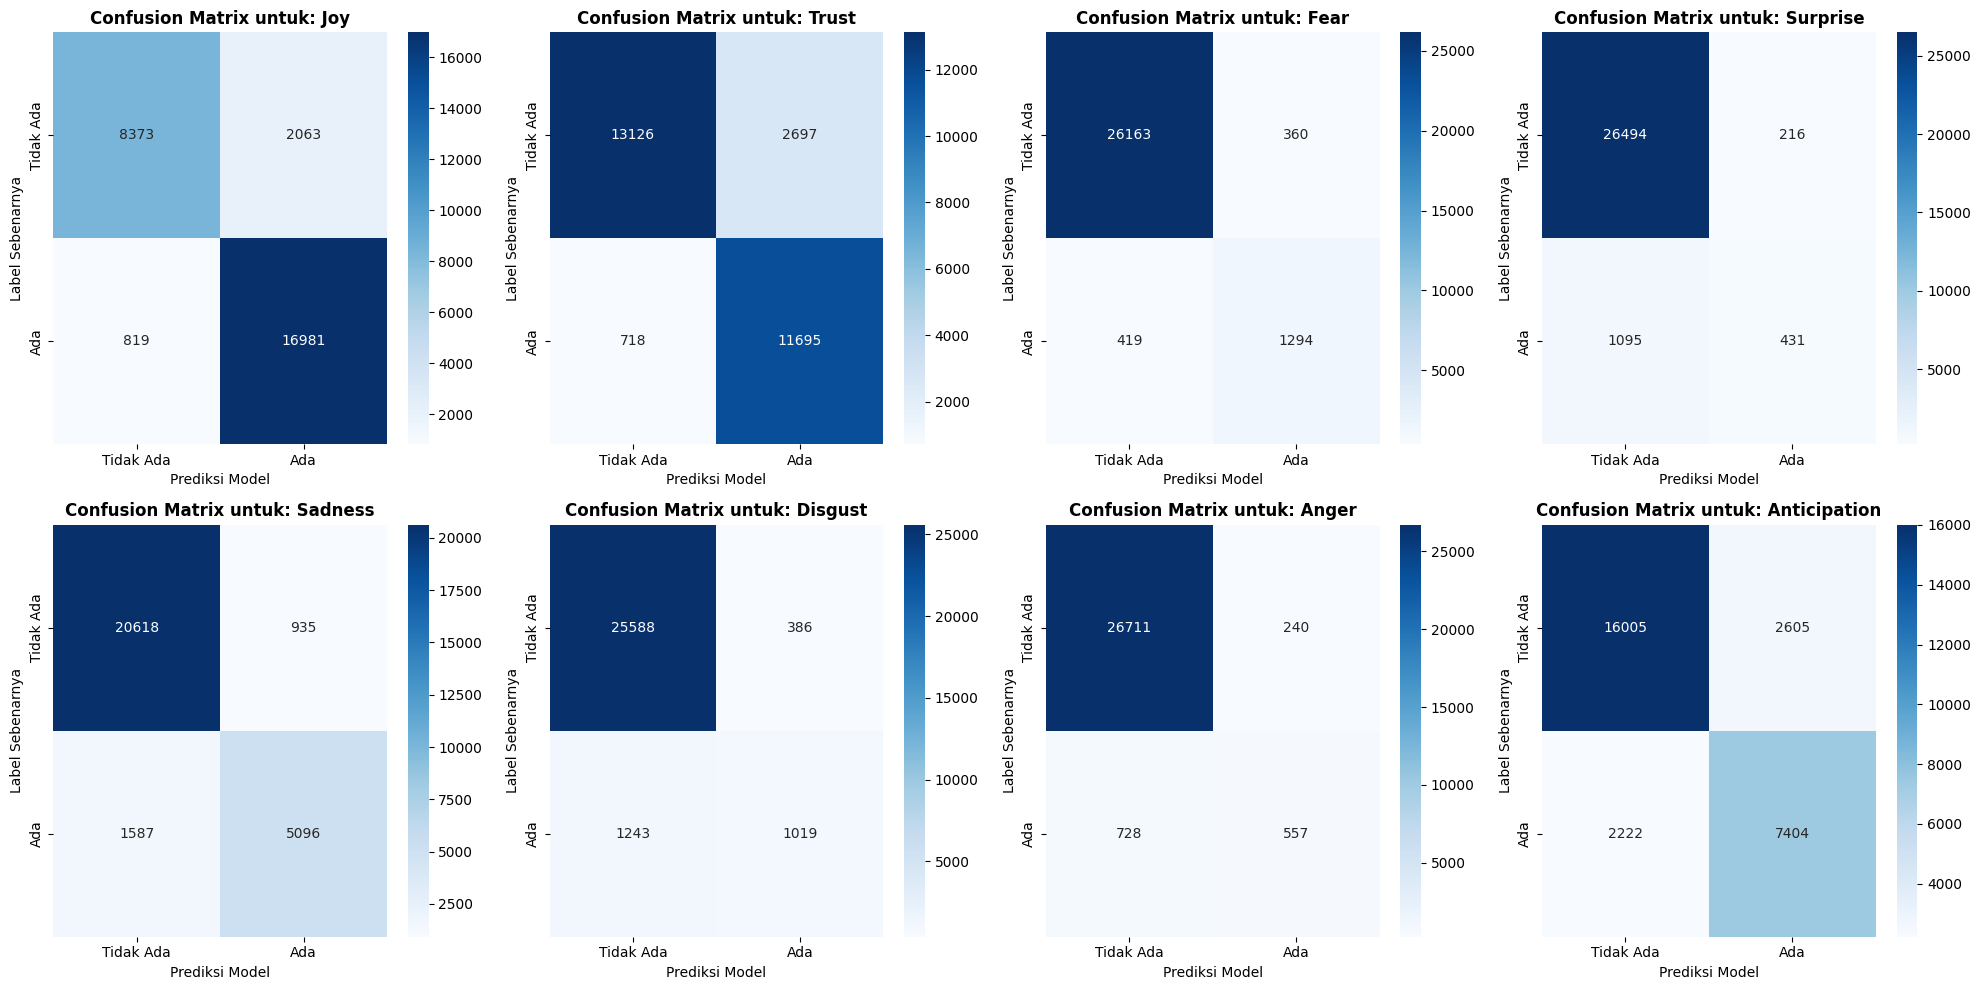

In [ ]:
import numpy as np
import torch
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
import wandb # Make sure wandb is imported

# --- 1. Evaluate on Test Set and Get Predictions ---
print("\nMengevaluasi model terbaik pada test set...")
evaluation_results = trainer.evaluate(eval_dataset=test_dataset) # Corrected variable name
print("\nHasil Evaluasi Akhir:")
print(evaluation_results)

print("\nMelakukan prediksi pada test set untuk membuat confusion matrix...")
prediction_output = trainer.predict(test_dataset) # Corrected variable name
logits = prediction_output.predictions
true_labels = prediction_output.label_ids
sigmoid = torch.nn.Sigmoid()
probs = sigmoid(torch.from_numpy(logits))
predictions = (probs > 0.5).int().numpy()

# --- 2. [MOVED UP] Define Paths and Create Directories ---
final_model_path = "./fine_tuned_indobert_emoji_fusion"
os.makedirs(final_model_path, exist_ok=True) # Create directory right away

# --- 3. Generate, Save, and Log the Confusion Matrix Plot ---
print("\nMembuat plot confusion matrix...")
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()
for i, label_name in enumerate(label_columns):
    cm = confusion_matrix(y_true=true_labels[:, i], y_pred=predictions[:, i])
    ax = axes[i]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, xticklabels=['Tidak Ada', 'Ada'], yticklabels=['Tidak Ada', 'Ada'])
    ax.set_title(f"Confusion Matrix untuk: {label_name.title()}", fontweight='bold')
    ax.set_xlabel('Prediksi Model')
    ax.set_ylabel('Label Sebenarnya')

plt.tight_layout()

# Save the plot as a PNG file
plot_path = f"{final_model_path}/confusion_matrix.png"
plt.savefig(plot_path, dpi=300)
print(f"Confusion matrix saved as an image to: {plot_path}")

# Log the plot to Weights & Biases
if training_args.report_to == "wandb":
    print("Logging confusion matrix plot to W&B...")
    wandb.log({"confusion_matrix": wandb.Image(plt)})

# Display the plot in the notebook
plt.show()
plt.close()

# LANGKAH 8: MENYIMPAN MODEL DAN TOKENIZER FINAL
## [MODIFIED] Menyimpan model yang sudah di-fine-tuning. Perhatikan bahwa ini hanya menyimpan state_dict dari model kustom kita.

In [ ]:
# --- 4. Save the Model and Tokenizer ---
print(f"\nMenyimpan model dan tokenizer final ke '{final_model_path}'...")
torch.save(model.state_dict(), f"{final_model_path}/pytorch_model.bin")
tokenizer.save_pretrained(final_model_path)
with open(f"{final_model_path}/emoji_to_id.json", 'w') as f:
    json.dump(emoji_to_id, f)
print("Model, tokenizer, dan vocab emoji berhasil disimpan.")

# --- 5. Log Final Metrics and Finish W&B Run ---
if training_args.report_to == "wandb":
    print("\nLogging final test results to W&B...")
    test_results_for_wandb = {f"test/{k.split('_')[-1]}": v for k, v in evaluation_results.items()}
    wandb.summary.update(test_results_for_wandb)
    wandb.finish()
    print("W&B run finished.")

# [NEW] Contoh cara memuat kembali model kustom:
# 1. Inisialisasi ulang arsitektur model:
#    loaded_model = BertEmojiFusionModel(model_name, num_labels, EMOJI_VOCAB_SIZE, EMOJI_EMBEDDING_DIM)
# 2. Muat state_dict yang disimpan:
#    loaded_model.load_state_dict(torch.load(f"{final_model_path}/pytorch_model.bin"))
# 3. Pindahkan model ke device yang sesuai:
#    loaded_model.to('cuda' if torch.cuda.is_available() else 'cpu')




Menyimpan model dan tokenizer final ke './fine_tuned_indobert_emoji_fusion'...
Model, tokenizer, dan vocab emoji berhasil disimpan.


## Simpan ke Google Drive

In [ ]:
from google.colab import drive
import os
import shutil

# Mount Google Drive
print("Mounting Google Drive...")
drive.mount('/content/drive')

# Tentukan path folder sumber yang ingin disimpan
source_folder = "./fine_tuned_indobert_emoji_fusion"

# Tentukan path tujuan di Google Drive
# Pastikan folder 'fine_tuned_indobert_early_fusion_concat' ada di root Google Drive Anda atau sesuaikan path
drive_save_path = "/content/drive/MyDrive/fine_tuned_indobert_early_fusion_concat/training 8" # Nama folder training 2

# Buat direktori tujuan di Google Drive jika belum ada
if not os.path.exists(drive_save_path):
    os.makedirs(drive_save_path)
    print(f"Direktori tujuan '{drive_save_path}' dibuat.")
else:
    print(f"Direktori tujuan '{drive_save_path}' sudah ada.")

# Menyalin seluruh isi folder sumber ke folder tujuan di Google Drive
print(f"\nMenyalin folder '{source_folder}' ke '{drive_save_path}'...")
try:
    # Gunakan shutil.copytree untuk menyalin seluruh folder
    # dirs_exist_ok=True memungkinkan penyalinan bahkan jika direktori tujuan sudah ada
    shutil.copytree(source_folder, drive_save_path, dirs_exist_ok=True)
    print("Folder berhasil disalin ke Google Drive.")
except Exception as e:
    print(f"Error saat menyalin folder: {e}")

# [OLD] Garis di bawah ini dihapus karena kita menyalin seluruh folder, bukan hanya menggunakan trainer.save_model
# trainer.save_model(drive_save_path)
# tokenizer.save_pretrained(drive_save_path)
# print("Model dan tokenizer berhasil disimpan di Google Drive.")

Mounting Google Drive...
Mounted at /content/drive
Direktori tujuan '/content/drive/MyDrive/fine_tuned_indobert_early_fusion_concat/training 8' dibuat.

Menyalin folder './fine_tuned_indobert_emoji_fusion' ke '/content/drive/MyDrive/fine_tuned_indobert_early_fusion_concat/training 8'...
Folder berhasil disalin ke Google Drive.
